# Generative AI with LSTM – Shakespeare Text Generation

# Setup and Configuration

In [ ]:
import os
import re
import pickle
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATA_PATH = "data\shakespeare.txt"
MODEL_DIR = "models"
OUTPUT_DIR = "outputs"
MODEL_PATH = os.path.join(MODEL_DIR, "best_lstm_model.keras")
TOKENIZER_PATH = os.path.join(MODEL_DIR, "tokenizer.pkl")
SAMPLES_PATH = os.path.join(OUTPUT_DIR, "generated_samples.txt")

SEQUENCE_LENGTH = 20
EMBEDDING_DIM = 128
LSTM_UNITS = 256
DROPOUT_RATE = 0.2
BATCH_SIZE = 128
EPOCHS = 6  # for limited time I use only 6 epoches (but we have to use more epoches)
LEARNING_RATE = 0.001
TRAIN_SPLIT = 0.80

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("TensorFlow:", tf.__version__)


TensorFlow: 2.21.0


# Load the Shakespeare Dataset

In [2]:
with open(DATA_PATH, "r", encoding="utf-8") as f:
    raw_text = f.read()

print("Characters:", len(raw_text))
print("\nFirst 1000 characters:\n")
print(raw_text[:1000])

Characters: 5378701

First 1000 characters:

The Project Gutenberg eBook of The Complete Works of William Shakespeare
    
This eBook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with almost no restrictions
whatsoever. You may copy it, give it away or re-use it under the terms
of the Project Gutenberg License included with this eBook or online
at www.gutenberg.org. If you are not located in the United States,
you will have to check the laws of the country where you are located
before using this eBook.

Title: The Complete Works of William Shakespeare

Author: William Shakespeare


        
Release date: January 1, 1994 [eBook #100]
                Most recently updated: August 24, 2025

Language: English

Other information and formats: www.gutenberg.org/ebooks/100


*** START OF THE PROJECT GUTENBERG EBOOK THE COMPLETE WORKS OF WILLIAM SHAKESPEARE ***




The Complete Works of William Shakespeare

by William Shakespeare




   

# Preprocessing

Steps:
1. Convert text to lowercase.
2. Remove punctuation and special characters.
3. Normalize repeated whitespace.

In [3]:
text = raw_text.lower()
text = re.sub(r"[^a-z0-9\s]", "", text)
text = re.sub(r"\s+", " ", text).strip()

print("Cleaned characters:", len(text))
print("\nCleaned sample:\n")
print(text[:1000])

Cleaned characters: 5040206

Cleaned sample:

the project gutenberg ebook of the complete works of william shakespeare this ebook is for the use of anyone anywhere in the united states and most other parts of the world at no cost and with almost no restrictions whatsoever you may copy it give it away or reuse it under the terms of the project gutenberg license included with this ebook or online at wwwgutenbergorg if you are not located in the united states you will have to check the laws of the country where you are located before using this ebook title the complete works of william shakespeare author william shakespeare release date january 1 1994 ebook 100 most recently updated august 24 2025 language english other information and formats wwwgutenbergorgebooks100 start of the project gutenberg ebook the complete works of william shakespeare the complete works of william shakespeare by william shakespeare contents the sonnets alls well that ends well the tragedy of antony and cleopatr

# Word-Level Tokenization

In [4]:
tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts([text])

token_list = tokenizer.texts_to_sequences([text])[0]
total_words = len(tokenizer.word_index) + 1

print("Vocabulary size:", total_words)
print("Total tokens:", len(token_list))
print("First 30 token IDs:", token_list[:30])

Vocabulary size: 30511
Total tokens: 966362
First 30 token IDs: [2, 1041, 1176, 4788, 6, 2, 3189, 1475, 6, 1153, 5937, 20, 4788, 12, 17, 2, 306, 6, 4380, 5938, 10, 2, 3613, 2291, 3, 108, 159, 870, 6, 2]


# Create Input → Next-Token Pairs

In [5]:
input_sequences = []

for i in range(SEQUENCE_LENGTH, len(token_list)):
    sequence = token_list[i-SEQUENCE_LENGTH:i+1]
    input_sequences.append(sequence)

input_sequences = np.array(input_sequences, dtype=np.int32)
X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (966342, 20)
y shape: (966342,)


In [6]:
index_to_word = {index: word for word, index in tokenizer.word_index.items()}

def decode_tokens(tokens):
    return " ".join(index_to_word.get(int(t), "<UNK>") for t in tokens)

print("Example input:", decode_tokens(X[0]))
print("Expected next word:", index_to_word.get(int(y[0]), "<UNK>"))

Example input: the project gutenberg ebook of the complete works of william shakespeare this ebook is for the use of anyone anywhere
Expected next word: in


# Train / Validation Split

An 80/20 sequential split is used.


In [7]:
split_index = int(len(X) * TRAIN_SPLIT)

X_train, X_val = X[:split_index], X[split_index:]
y_train, y_val = y[:split_index], y[split_index:]

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))

Training samples: 773073
Validation samples: 193269


# Build the LSTM Model

Architecture:

**Embedding → LSTM → Dropout → LSTM → Dropout → Dense Softmax**

Sparse categorical cross-entropy is used because the targets are integer token IDs rather than one-hot vectors.


In [8]:
model = Sequential([
    Embedding(input_dim=total_words, output_dim=EMBEDDING_DIM),
    LSTM(LSTM_UNITS, return_sequences=True),
    Dropout(DROPOUT_RATE),
    LSTM(LSTM_UNITS),
    Dropout(DROPOUT_RATE),
    Dense(total_words, activation="softmax")
])

model.build(input_shape=(None, SEQUENCE_LENGTH))

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 20, 128)             │       3,905,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 20, 256)             │         394,240 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 20, 256)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 256)                 │         525,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 30511)               │       7,841,327 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,666,287 (48.32 MB)

 Trainable params: 12,666,287 (48.32 MB)

 Non-trainable params: 0 (0.00 B)

# Train with Early Stopping and Checkpointing

In [9]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        MODEL_PATH,
        monitor="val_loss",
        save_best_only=True
    )
]

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
6040/6040 ━━━━━━━━━━━━━━━━━━━━ 1684s 278ms/step - accuracy: 0.0564 - loss: 6.7542 - val_accuracy: 0.0720 - val_loss: 6.8255
Epoch 2/10
6040/6040 ━━━━━━━━━━━━━━━━━━━━ 1597s 264ms/step - accuracy: 0.0900 - loss: 6.1769 - val_accuracy: 0.0856 - val_loss: 6.6746
Epoch 3/10
6040/6040 ━━━━━━━━━━━━━━━━━━━━ 1558s 258ms/step - accuracy: 0.1017 - loss: 5.8822 - val_accuracy: 0.0923 - val_loss: 6.6737
Epoch 4/10
6040/6040 ━━━━━━━━━━━━━━━━━━━━ 1534s 254ms/step - accuracy: 0.1085 - loss: 5.6757 - val_accuracy: 0.0958 - val_loss: 6.7220
Epoch 5/10
6040/6040 ━━━━━━━━━━━━━━━━━━━━ 1529s 253ms/step - accuracy: 0.1135 - loss: 5.5164 - val_accuracy: 0.0983 - val_loss: 6.7948
Epoch 6/10
6040/6040 ━━━━━━━━━━━━━━━━━━━━ 1529s 253ms/step - accuracy: 0.1185 - loss: 5.3854 - val_accuracy: 0.0991 - val_loss: 6.8499


In [10]:
with open(TOKENIZER_PATH, "wb") as f:
    pickle.dump(tokenizer, f)

print("Best model:", MODEL_PATH)
print("Tokenizer:", TOKENIZER_PATH)

Best model: models\best_lstm_model.keras
Tokenizer: models\tokenizer.pkl


# Training Curves

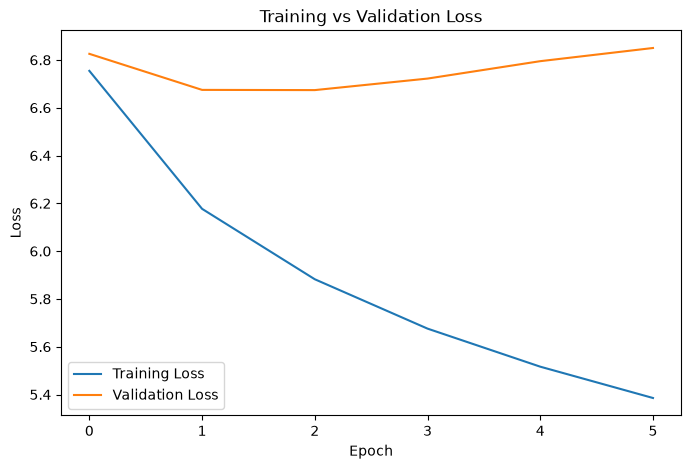

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

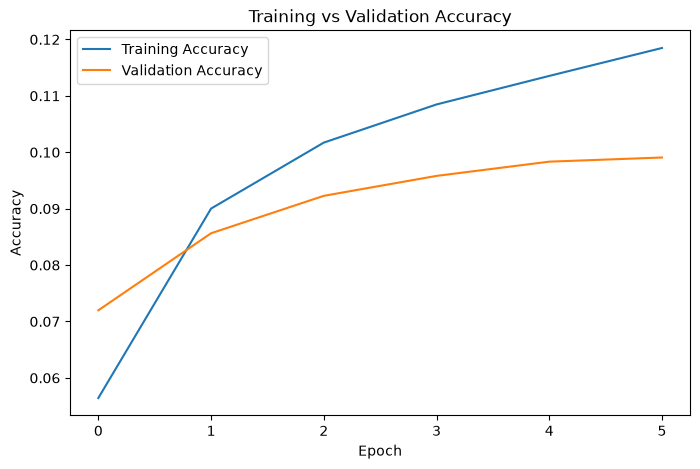

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

# Evaluate the Best Model

In [13]:
best_model = load_model(MODEL_PATH)

val_loss, val_accuracy = best_model.evaluate(
    X_val, y_val, verbose=0
)

print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")

Validation Loss: 6.6737
Validation Accuracy: 0.0923


# Text Generation with Temperature Sampling

In [14]:
def generate_text(seed_text, next_words=50, temperature=0.8):
    generated_text = seed_text.lower()

    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([generated_text])[0]
        token_list = token_list[-SEQUENCE_LENGTH:]

        token_list = pad_sequences(
            [token_list],
            maxlen=SEQUENCE_LENGTH,
            padding="pre"
        )

        predictions = best_model.predict(token_list, verbose=0)[0]
        predictions = np.asarray(predictions, dtype=np.float64)

        predictions = np.log(predictions + 1e-8) / temperature
        probabilities = np.exp(predictions)
        probabilities /= np.sum(probabilities)

        next_token = np.random.choice(
            len(probabilities),
            p=probabilities
        )

        next_word = index_to_word.get(next_token, "")

        if next_word and next_word != "<OOV>":
            generated_text += " " + next_word

    return generated_text

# Generate Sample Shakespeare-Like Text

In [15]:
seeds = [
    "to be or not to",
    "the king shall",
    "love is a smoke",
    "friends romans countrymen"
]

samples = []

for seed in seeds:
    generated = generate_text(
        seed,
        next_words=50,
        temperature=0.8
    )
    samples.append((seed, generated))

    print("\n" + "=" * 80)
    print("SEED:", seed)
    print("GENERATED:", generated)


SEED: to be or not to
GENERATED: to be or not to do those maid are a great no trade but now the legate is a time to do it he is no more for you have given you by this a mans sweet lord theseus regan these are the fury of the happy and following i think you are but a

SEED: the king shall
GENERATED: the king shall instruct thee dumaine exit macbeth exeter and this and we all this virtuous true shall be of friends and lowly sway to the proceeding of all hath i never with such since you have some many treason as speak of the worlds innocent end for in my sword the great

SEED: love is a smoke
GENERATED: love is a smoke and sense a marriage tells me that more with the field and moves out with heaven upon the nativity of all tears i have this light body lets i tell what i have been perfect that you say in pleasd fit to do my life and how he is that

SEED: friends romans countrymen
GENERATED: friends romans countrymen fast of the chief schedule of our kindness that which he had brought him 

In [16]:
with open(SAMPLES_PATH, "w", encoding="utf-8") as f:
    for seed, generated in samples:
        f.write("SEED: " + seed + "\n")
        f.write("GENERATED: " + generated + "\n")
        f.write("\n" + "-" * 80 + "\n\n")

print("Samples saved to:", SAMPLES_PATH)


Samples saved to: outputs\generated_samples.txt


In [17]:
def build_lstm_model(
    vocabulary_size,
    sequence_length,
    lstm_layers=2,
    embedding_dim=128,
    lstm_units=256
):
    layers = [Embedding(vocabulary_size, embedding_dim)]

    for i in range(lstm_layers):
        layers.append(
            LSTM(
                lstm_units,
                return_sequences=(i < lstm_layers - 1)
            )
        )
        layers.append(Dropout(0.2))

    layers.append(Dense(vocabulary_size, activation="softmax"))

    experiment_model = Sequential(layers)

    experiment_model.build(
        input_shape=(None, sequence_length)
    )

    experiment_model.compile(
        optimizer=tf.keras.optimizers.Adam(0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return experiment_model

experiment_model = build_lstm_model(
    total_words,
    SEQUENCE_LENGTH,
    lstm_layers=2
)

experiment_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ (None, 20, 128)             │       3,905,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 20, 256)             │         394,240 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 20, 256)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 256)                 │         525,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 30511)               │       7,841,327 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,666,287 (48.32 MB)

 Trainable params: 12,666,287 (48.32 MB)

 Non-trainable params: 0 (0.00 B)